# Figure 3: Chromatin and Gene Expression

**Goal:**

Show the relationship of the chromatin and gene expression with respect to cell phases. What patterns are different per cell phase?

**Procedure:**
1. Partition out the genes by where there maximal expression lies (criteria: expression is 1.5 greater in the phase than any other phase). Quantify this.
2. Then, plot the 90/10 PTR ratio for the chromatin for each of these highly expressed genes
3. Are there any discernible patterns in the chromatin for each cell phase?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.Figure3_Chrom_Gene_Expression import Figure3_Chrom_GeneExpression

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_07_23/'

figures = Figure3_Chrom_GeneExpression(outdir)


In [19]:
figures.partition_genes_phases()

In [10]:
figures.load_ptrs()

In [14]:
figures.correct_ptr_imgs()

In [33]:
figures.select_k_genes()

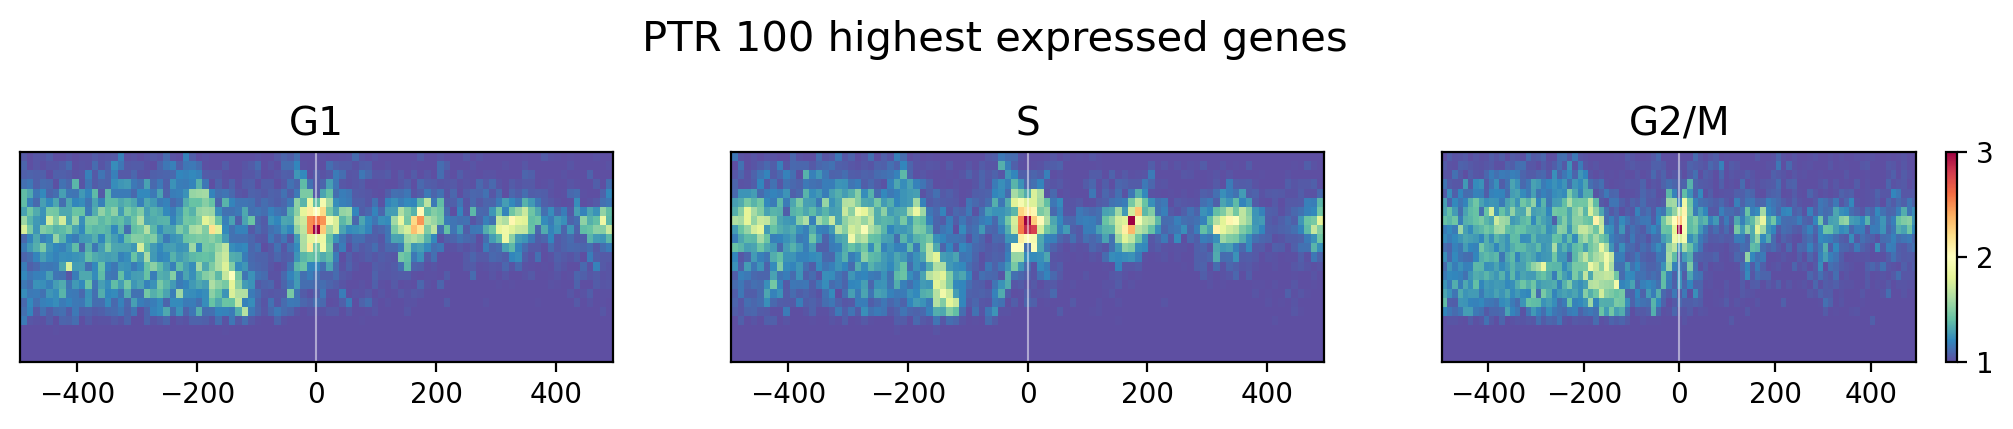

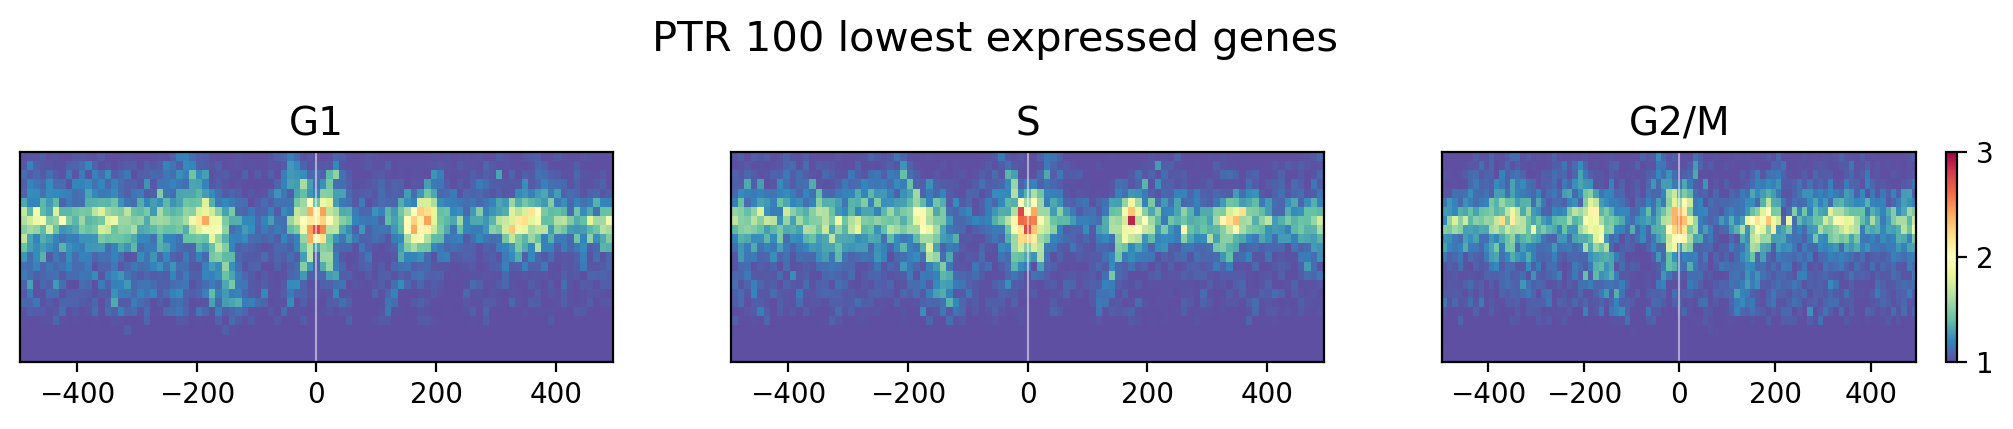

In [31]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

figures.plot_gene_ptrs_phase(True)
save_figure_for_paper('output/figures/Expression_Chromatin/PTR_phases_top.png')

figures.plot_gene_ptrs_phase(False)
save_figure_for_paper('output/figures/Expression_Chromatin/PTR_phases_bottom.png')

In [62]:
print("The highest gene expression medians for each phase:")
print("G1:   {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.top_k_g1_expression, 
                                                      [0.5, 0.05, 0.95])))))
print("S:    {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.top_k_s_expression, 
                                                      [0.5, 0.05, 0.95])))))
print("G2M:  {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.top_k_g2m_expression, 
                                                      [0.5, 0.05, 0.95])))))

The highest gene expression medians for each phase:
G1:   15.17 (14.08 17.41)
S:    14.01 (13.20 16.07)
G2M:  16.19 (15.50 18.46)


In [64]:
print("The lowest gene expression medians for each phase:")
print("G1:   {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.bottom_k_g1_expression, 
                                                      [0.5, 0.05, 0.95])))))
print("S:    {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.bottom_k_s_expression, 
                                                      [0.5, 0.05, 0.95])))))
print("G2M:  {:.2f} ({:.2f} {:.2f})".format(*tuple(list(np.quantile(figures.bottom_k_g2m_expression, 
                                                      [0.5, 0.05, 0.95])))))

The lowest gene expression medians for each phase:
G1:   5.95 (4.71 6.82)
S:    5.71 (4.63 6.55)
G2M:  5.95 (4.57 7.01)


In [ ]:
# Will need a story to help motivate the direction of this analysis
# Currently there could be something about G2/M gene expression showing differential
# chromatin dynamics wrt to the +1 nucleosome, it is also the phase with the highest
# median expression.

# Promoter, +1 and +2 appear to be clear PTR signals among the highly expressed genes...
# the promoter especially as the lowly expressed genes have cycling nucleosomes as well


In [80]:
# Show as tiers of expression levels
figures.gene_expression_a.gene_expression_f

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067W-A,4.463945,4.463914,4.463853,4.463756,4.463626,4.463469,4.463288,4.463085,4.462863,4.462614,...,4.42355,4.423455,4.423392,4.423339,4.42334,4.423369,4.42327,4.423,4.422517,4.049438
YAL067C,13.807611,13.651602,13.352539,12.89924,12.313786,11.695589,11.065469,10.448315,9.862124,9.267386,...,5.177838,5.101288,5.018962,4.935756,4.845655,4.752154,4.709288,4.729759,4.76748,9.918408
YAL064C-A,4.758446,4.760381,4.764233,4.76998,4.777596,4.786938,4.797866,4.810613,4.825039,4.840312,...,4.982603,4.979295,4.976096,4.973119,4.970304,4.967737,4.966005,4.965224,4.965012,5.454661
YAL064W,5.230384,5.228947,5.226231,5.221929,5.21618,5.210086,5.203801,5.197219,5.190542,5.183711,...,4.982603,4.975947,4.969125,4.962273,4.95543,4.94876,4.943059,4.938368,4.935238,5.039218
YAL063C-A,6.147748,6.146841,6.145123,6.142422,6.138819,6.134952,6.130914,6.126623,6.12221,6.117678,...,5.976439,5.974783,5.97336,5.971997,5.971413,5.971649,5.969781,5.965541,5.96225,5.943495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR198W,13.065703,13.032464,12.968293,12.8714,12.74557,12.60918,12.466181,12.318881,12.171251,12.020102,...,10.67861,10.677654,10.676686,10.67572,10.674746,10.673771,10.672923,10.672212,10.671556,10.542347
YPR199C,9.69517,9.694564,9.693363,9.691555,9.689145,9.68624,9.682886,9.67898,9.674571,9.669909,...,9.583128,9.583119,9.58311,9.583101,9.583094,9.583091,9.583091,9.583096,9.583103,8.911381
YPR200C,7.48503,7.484677,7.484004,7.482956,7.481577,7.480087,7.478512,7.476929,7.475382,7.473675,...,7.017949,7.018459,7.018644,7.018336,7.018234,7.018408,7.016612,7.012783,7.009839,5.395115
